# LLM-as-router: can a language model do the routing itself?

The last of the instructor's three suggestions, and the only one that needed genuinely
new work: instead of a trained classifier, hand each request to an LLM together with
the model menu and let it choose. I first tried gemini-2.5-flash-lite on the free tier,
but the daily request quota throttled the run to a crawl (33 usable picks in a full
day of retries), so I moved the router to claude-haiku-4.5 on a paid key. The routing
model still has to be cheap for the idea to make any economic sense; the whole
300-prompt run came to roughly a quarter of a dollar.

Setup decisions. The router sees the same information regime the trained models had:
the request text plus a menu built from training data only (each model's average cost
per request and the share of training prompts it solved). Request text is truncated to
1,500 characters, a router deciding where to send a request should not need to read a
20-page diff in full. I ran a stratified sample of 300 test prompts rather than all
2,434: the comparison needs matched prompts, not volume, and every other strategy is
re-scored on the identical sample so the points stay comparable. Responses are cached
to a parquet and the cache is resumable: successful picks are never re-billed, failed
ones get retried on the next run.


In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from dotenv import load_dotenv
from sklearn.model_selection import train_test_split

proc = Path("..") / "data" / "processed"
long_df = pd.read_parquet(proc / "records_long.parquet")
core = long_df[~long_df.is_reference]
openrouter = long_df[long_df.is_reference]
model_df = pd.read_parquet(proc / "prompts_features_labels_tau100.parquet")
queries = pd.read_parquet(proc / "queries.parquet").set_index("prompt_id")["query"]
router_preds = pd.read_parquet(proc / "router_test_predictions.parquet")
reg_picks = pd.read_parquet(proc / "regressor_test_picks.parquet")

train_df, test_df = train_test_split(
    model_df, test_size=0.2, random_state=42, stratify=model_df.dataset)

# stratified 300-prompt sample of the test set
sample_df, _ = train_test_split(
    test_df, train_size=300, random_state=42, stratify=test_df.dataset)
print("sample by dataset:")
print(sample_df.dataset.value_counts())

sample by dataset:
dataset
simpleqa         107
mmlupro           74
hle               53
livecodebench     26
arenahard         19
swe-bench         12
gpqa               5
livemathbench      3
aime               1
Name: count, dtype: int64


In [2]:
# the menu the router reads: built from TRAIN prompts only
train_rows = core[core.prompt_id.isin(train_df.prompt_id)]
menu_stats = train_rows.groupby("model").agg(
    avg_cost=("cost", "mean"), solve_rate=("score", lambda s: (s >= 1.0).mean()))
menu_stats = menu_stats.sort_values("avg_cost")
menu_text = "\n".join(
    f"- {m}: avg cost ${r.avg_cost:.4f} per request, solves {r.solve_rate:.0%} of requests"
    for m, r in menu_stats.iterrows())
print(menu_text)

- deepseek-v3-0324: avg cost $0.0008 per request, solves 41% of requests
- qwen3-235b-a22b-2507: avg cost $0.0008 per request, solves 53% of requests
- deepseek-v3.1-terminus: avg cost $0.0010 per request, solves 44% of requests
- kimi-k2-0905: avg cost $0.0015 per request, solves 44% of requests
- intern-s1: avg cost $0.0028 per request, solves 37% of requests
- gpt-5-chat: avg cost $0.0049 per request, solves 47% of requests
- qwen3-235b-a22b-thinking-2507: avg cost $0.0075 per request, solves 52% of requests
- gemini-2.5-flash: avg cost $0.0086 per request, solves 43% of requests
- claude-sonnet-4: avg cost $0.0103 per request, solves 38% of requests
- deepseek-r1-0528: avg cost $0.0131 per request, solves 47% of requests
- glm-4.6: avg cost $0.0147 per request, solves 44% of requests
- gpt-5: avg cost $0.0294 per request, solves 58% of requests
- gemini-2.5-pro: avg cost $0.0597 per request, solves 59% of requests


In [3]:
ROUTER_MODEL = "claude-haiku-4-5-20251001"  # the router must cost less than the savings it finds
TRUNCATE = 1500
CACHE = proc / "llm_router_picks_haiku.parquet"

PROMPT_TEMPLATE = (
    "You route user requests to the most economical AI model. Below is a menu of "
    "models with their average cost per request in USD and the share of requests "
    "each solves correctly, then one user request. Pick the single cheapest model "
    "you expect to solve THIS request correctly. Reply with the model name only, "
    "nothing else.\n\nMENU:\n{menu}\n\nREQUEST (may be truncated):\n{request}"
)

valid_names = set(menu_stats.index)
cheapest_model = menu_stats.avg_cost.idxmin()

# resumable cache, kept from the gemini attempt: successful picks are stored
# forever, anything else is retried. The first overnight run on the free tier
# lost 277 of 300 calls to rate limiting, which is why the router now runs on
# a paid key, but the cache still means an interrupted run only pays for what
# is missing.
if CACHE.exists():
    prior = pd.read_parquet(CACHE)
    done = prior[prior.status == "ok"][["prompt_id", "raw", "status"]]
else:
    done = pd.DataFrame(columns=["prompt_id", "raw", "status"])
todo = [p for p in sample_df.prompt_id if p not in set(done.prompt_id)]
print(f"{len(done)} picks cached, {len(todo)} to fetch")

if todo:
    import requests

    load_dotenv(Path("..") / ".env")
    api_key = os.environ["ANTHROPIC_API_KEY"]
    API_URL = "https://api.anthropic.com/v1/messages"
    HEADERS = {"x-api-key": api_key, "anthropic-version": "2023-06-01",
               "content-type": "application/json"}

    def ask_router(prompt_id):
        text = PROMPT_TEMPLATE.format(
            menu=menu_text, request=queries.loc[prompt_id][:TRUNCATE])
        body = {"model": ROUTER_MODEL, "max_tokens": 50, "temperature": 0,
                "messages": [{"role": "user", "content": text}]}
        # two attempts max, with a short pause to ride out transient errors
        for attempt in range(2):
            try:
                resp = requests.post(API_URL, headers=HEADERS, json=body, timeout=60)
                resp.raise_for_status()
                answer = resp.json()["content"][0]["text"].strip().strip('"').strip("`")
                if answer in valid_names:
                    return prompt_id, answer, "ok"
                return prompt_id, answer, "invalid"
            except Exception:
                time.sleep(10)
        return prompt_id, None, "failed"

    def save_progress(rows):
        # write the cache after every chunk so an interrupted run loses at
        # most a few calls instead of all of them
        df = pd.concat([done, pd.DataFrame(rows, columns=["prompt_id", "raw", "status"])],
                       ignore_index=True)
        df["pick"] = df.apply(
            lambda r: r.raw if r.status == "ok" else cheapest_model, axis=1)
        df.to_parquet(CACHE, index=False)
        return df

    results = []
    for i, pid in enumerate(todo):
        results.append(ask_router(pid))
        time.sleep(1.5)  # stays under the paid-tier per-minute request limit
        if (i + 1) % 15 == 0:
            save_progress(results)
    llm_picks_df = save_progress(results)
else:
    llm_picks_df = done.copy()
    llm_picks_df["pick"] = llm_picks_df.apply(
        lambda r: r.raw if r.status == "ok" else cheapest_model, axis=1)
print("saved picks to cache")

print(llm_picks_df.status.value_counts().to_dict())
print("\ntraffic shares chosen by the LLM router:")
print(llm_picks_df.pick.value_counts(normalize=True).round(3).head(8))


286 picks cached, 14 to fetch


saved picks to cache
{'ok': 287, 'invalid': 13}

traffic shares chosen by the LLM router:
pick
qwen3-235b-a22b-2507    0.953
deepseek-v3-0324        0.043
gpt-5                   0.003
Name: proportion, dtype: float64


The router put 95% of its traffic on qwen3-235b-a22b-2507, the second-cheapest
model on the menu and the one with the best solve rate among the cheap options.
287 of the 300 replies were a clean model name. The other 13 came back with haiku
starting to solve the request itself instead of naming a model (mostly the hard
math and code prompts), and those fall back to the cheapest model. It barely
touched the rest of the menu: a single gpt-5 pick and nothing else above a tenth
of a cent.

So the LLM effectively rediscovered the notebook 05 finding on its own: qwen3-2507
at $0.0008 per request is the menu's anomaly, and "send almost everything there"
is close to the best simple policy those menu stats support.


In [4]:
# every strategy re-scored on the identical 300 prompts
sample_rows = core[core.prompt_id.isin(sample_df.prompt_id)]
lookup = sample_rows.set_index(["prompt_id", "model"])[["cost", "score"]]

def outcome(picks):
    got = lookup.loc[list(zip(picks.index, picks.values, strict=True))]
    return got.cost.mean(), got.score.mean()

fixed = sample_rows.groupby("model").agg(cost=("cost", "mean"),
                                         score=("score", "mean"))
sid = sample_df.prompt_id
strategies = {
    "always cheapest": pd.Series(fixed.cost.idxmin(), index=sid),
    "always strongest": pd.Series(fixed.score.idxmax(), index=sid),
    "logistic router (tuned)": router_preds.set_index("prompt_id").logistic_tuned.loc[sid],
    "random forest router (tuned)": router_preds.set_index(
        "prompt_id").random_forest_tuned.loc[sid],
    "regressor-derived router": reg_picks.set_index("prompt_id").regressor_routing.loc[sid],
    "LLM-as-router (claude-haiku-4.5)": llm_picks_df.set_index("prompt_id")["pick"].loc[sid],
    "oracle label": sample_df.set_index("prompt_id").label,
}
rows = [{"strategy": k, "mean cost (USD)": outcome(p)[0], "mean score": outcome(p)[1]}
        for k, p in strategies.items()]
or_sample = openrouter[openrouter.prompt_id.isin(sid)]
rows.append({"strategy": "OpenRouter (reference)",
             "mean cost (USD)": or_sample.cost.mean(),
             "mean score": or_sample.score.mean()})
scoreboard = pd.DataFrame(rows).set_index("strategy")
scoreboard.round(4)

,mean cost (USD),mean score
strategy,,
always cheapest,0.0008,0.3767
always strongest,0.0569,0.6067
logistic router (tuned),0.0132,0.5383
random forest router (tuned),0.0073,0.5217
regressor-derived router,0.0006,0.4817
LLM-as-router (claude-haiku-4.5),0.0011,0.5017
oracle label,0.0066,0.8100
OpenRouter (reference),0.0216,0.4950


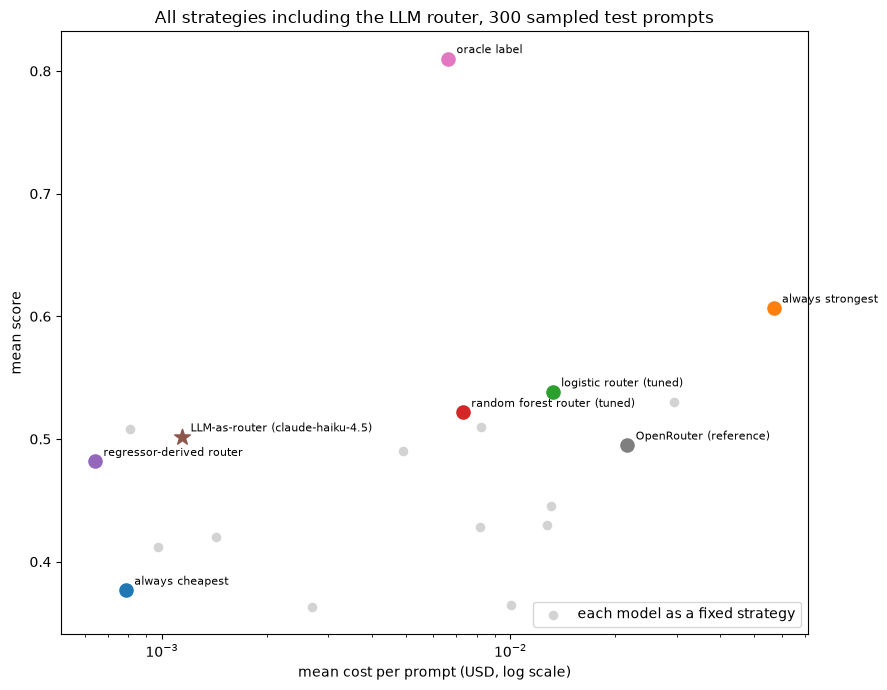

In [5]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(fixed.cost, fixed.score, color="lightgray", s=35, zorder=1,
           label="each model as a fixed strategy")
for name, row in scoreboard.iterrows():
    emph = "LLM-as-router" in name
    ax.scatter(row["mean cost (USD)"], row["mean score"], s=140 if emph else 90,
               zorder=3 if emph else 2, marker="*" if emph else "o")
    ax.annotate(name, (row["mean cost (USD)"], row["mean score"]), fontsize=8,
                xytext=(6, 4), textcoords="offset points")
ax.set_xscale("log")
ax.set_xlabel("mean cost per prompt (USD, log scale)")
ax.set_ylabel("mean score")
ax.set_title("All strategies including the LLM router, 300 sampled test prompts")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

On the matched 300-prompt sample the haiku router landed at $0.0011 mean cost and
0.50 mean score. That beats the regressor-derived router on score (0.48 at $0.0006)
and sits 2 to 4 points under the tuned classifiers at a tenth of their cost (random
forest 0.52 at $0.0073, logistic 0.54 at $0.0132). It also clears the OpenRouter
reference on both axes ($0.0216, 0.495).

Two caveats before reading too much into that. The scoreboard charges each strategy
only for the model it picked, but the LLM router also pays for its own haiku call,
roughly $0.0008 per request at these prompt lengths, which about doubles its
effective cost to $0.002. Still far under the tuned classifiers, though those pay
their inference cost in microseconds of CPU instead. And the router barely routed:
with 95% of traffic on one model, most of its score comes from qwen3-2507 being a
strong cheap default rather than from per-request discrimination. Same conclusion
notebook 05 reached with trained models: when one cheap model dominates the menu,
the smartest cheap policy is mostly a constant.
